In [17]:
import torch
import random
import pandas as pd
import io
import requests
from rdkit import Chem
from torch_geometric.data import Data

In [8]:
# We have 3 halogens x 3 positions = 9 classes
motifs = {
    # Chlorine
    0: ('[*]c1c(Cl)c(Cl)ccc1', 'Cl_Ortho'),
    1: ('[*]c1c(Cl)cc(Cl)cc1', 'Cl_Meta'),
    2: ('[*]c1c(Cl)ccc(Cl)c1', 'Cl_Para'),
    # Fluorine
    3: ('[*]c1c(F)c(F)ccc1', 'F_Ortho'),
    4: ('[*]c1c(F)cc(F)cc1', 'F_Meta'),
    5: ('[*]c1c(F)ccc(F)c1', 'F_Para'),
    # Bromine
    6: ('[*]c1c(Br)c(Br)ccc1', 'Br_Ortho'),
    7: ('[*]c1c(Br)cc(Br)cc1', 'Br_Meta'),
    8: ('[*]c1c(Br)ccc(Br)c1', 'Br_Para'),
}

In [9]:
def get_zinc_smiles(num_samples=1200):
    print(f"Downloading ZINC SMILES subset...")
    # We use a static URL to a clean ZINC subset (e.g., from a deeplychem repo or similar stable source)
    # Alternatively, we can use the AQSOL raw data URL.
    # Here I will use a direct raw GitHub link to a standard ZINC test set often used in benchmarking.
    url = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
    
    try:
        s = requests.get(url).content
        df = pd.read_csv(io.StringIO(s.decode('utf-8')))
        # The column is usually 'smiles' or similar. In this specific dataset it is likely the first column.
        # Let's clean it up.
        smiles_list = df.iloc[:, 0].tolist() # Assuming SMILES is 1st column
        print(f"Successfully loaded {len(smiles_list)} SMILES.")
        
        # Shuffle and pick needed amount
        random.shuffle(smiles_list)
        return smiles_list[:num_samples]
        
    except Exception as e:
        print(f"Error downloading SMILES: {e}")
        print("Falling back to dummy data for demonstration.")
        return ["CC1(C)CC(NC(=O)C2=CC=CO2)C1"] * num_samples

In [10]:
# ---------------------------------------------------------
# 3. GRAPH CONVERSION UTILS
# ---------------------------------------------------------
def get_one_hot_atom(atom_symbol):
    permitted_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
    if atom_symbol not in permitted_list: atom_symbol = 'C'
    return [int(atom_symbol == s) for s in permitted_list]

In [11]:
def get_one_hot_bond(bond):
    bond_types = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
                  Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]
    b_type = bond.GetBondType()
    if b_type not in bond_types: b_type = Chem.rdchem.BondType.SINGLE
    return [int(b_type == bt) for bt in bond_types]

In [12]:
def attach_motif(scaffold_mol, motif_smiles):
    motif = Chem.MolFromSmiles(motif_smiles)
    valid_atoms = [a.GetIdx() for a in scaffold_mol.GetAtoms() 
                   if a.GetSymbol() == 'C' and a.GetTotalNumHs() > 0]
    
    if not valid_atoms: return None, None 

    attach_idx = random.choice(valid_atoms)
    combined = Chem.RWMol(scaffold_mol)
    motif_atom_map = {} 
    dummy_idx = -1
    
    for atom in motif.GetAtoms():
        if atom.GetAtomicNum() == 0: 
            dummy_idx = atom.GetIdx(); continue
        motif_atom_map[atom.GetIdx()] = combined.AddAtom(atom)

    for bond in motif.GetBonds():
        s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if s == dummy_idx or e == dummy_idx: continue
        combined.AddBond(motif_atom_map[s], motif_atom_map[e], bond.GetBondType())

    dummy_atom = motif.GetAtomWithIdx(dummy_idx)
    neighbor_idx = motif_atom_map[dummy_atom.GetNeighbors()[0].GetIdx()]
    combined.AddBond(attach_idx, neighbor_idx, Chem.BondType.SINGLE)
    
    scaffold_atom = combined.GetAtomWithIdx(attach_idx)
    scaffold_atom.SetNumExplicitHs(max(0, scaffold_atom.GetTotalNumHs() - 1))
    
    try: Chem.SanitizeMol(combined)
    except: return None, None

    return combined, list(motif_atom_map.values())

In [13]:
def mol_to_pyg(mol, label, motif_indices):
    x = torch.tensor([get_one_hot_atom(a.GetSymbol()) for a in mol.GetAtoms()], dtype=torch.float)
    
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = get_one_hot_bond(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [feat, feat]

    if not edge_indices: return None # Skip single atoms
    
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    
    mask = torch.zeros(mol.GetNumAtoms(), dtype=torch.long)
    mask[motif_indices] = 1
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, 
                y=torch.tensor([label], dtype=torch.long), explanation_mask=mask)

In [18]:
scaffold_smiles_list = get_zinc_smiles(num_samples=1500) # Get slightly more to buffer failures

Successfully loaded 249455 SMILES.


In [25]:
import torch
import random
import pandas as pd
import io
import requests
from rdkit import Chem
from rdkit.Chem import AllChem
from torch_geometric.data import Data

# ---------------------------------------------------------
# 1. SETUP NEW MOTIFS (with Methyl Linker)
# ---------------------------------------------------------
# The attachment point [*] is now on a Carbon (C) that is 
# attached to the ring (c1...). This creates the scaffold-C-ring structure.
motifs = {
    # Chlorine
    0: ('[*]Cc1c(Cl)c(Cl)ccc1', 'Cl_Ortho_Methyl'),
    1: ('[*]Cc1c(Cl)cc(Cl)cc1', 'Cl_Meta_Methyl'),
    2: ('[*]Cc1c(Cl)ccc(Cl)c1', 'Cl_Para_Methyl'),
    # Fluorine
    3: ('[*]Cc1c(F)c(F)ccc1', 'F_Ortho_Methyl'),
    4: ('[*]Cc1c(F)cc(F)cc1', 'F_Meta_Methyl'),
    5: ('[*]Cc1c(F)ccc(F)c1', 'F_Para_Methyl'),
    # Bromine
    6: ('[*]Cc1c(Br)c(Br)ccc1', 'Br_Ortho_Methyl'),
    7: ('[*]Cc1c(Br)cc(Br)cc1', 'Br_Meta_Methyl'),
    8: ('[*]Cc1c(Br)ccc(Br)c1', 'Br_Para_Methyl'),
}

# ---------------------------------------------------------
# 2. HELPER: Get Real SMILES (ZINC subset)
# ---------------------------------------------------------
def get_zinc_smiles(num_samples=2000):
    print(f"Downloading ZINC SMILES subset...")
    url = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
    
    try:
        s = requests.get(url).content
        df = pd.read_csv(io.StringIO(s.decode('utf-8')))
        smiles_list = df.iloc[:, 0].tolist() 
        print(f"Successfully loaded {len(smiles_list)} SMILES.")
        random.shuffle(smiles_list)
        return smiles_list[:num_samples]
    except Exception as e:
        print(f"Error downloading SMILES: {e}")
        # Fallback dummy data
        return ["CC1(C)CC(NC(=O)C2=CC=CO2)C1"] * num_samples

# ---------------------------------------------------------
# 3. ROBUST GRAPH EDITING
# ---------------------------------------------------------
def attach_motif(scaffold_smiles, motif_smiles):
    """
    Robustly attaches a motif by replacing a real Hydrogen atom.
    """
    # 1. Prepare Scaffold with Explicit Hydrogens
    scaffold = Chem.MolFromSmiles(scaffold_smiles)
    if scaffold is None: return None, None
    scaffold = Chem.AddHs(scaffold)

    # 2. Find a Valid C-H Pair to substitute
    valid_pairs = []
    for atom in scaffold.GetAtoms():
        if atom.GetSymbol() == 'C':
            for neighbor in atom.GetNeighbors():
                if neighbor.GetSymbol() == 'H':
                    valid_pairs.append((atom.GetIdx(), neighbor.GetIdx()))
    
    if not valid_pairs: return None, None
    c_idx, h_idx = random.choice(valid_pairs)
    
    # 3. Prepare Motif
    motif = Chem.MolFromSmiles(motif_smiles)
    dummy_idx = -1
    for atom in motif.GetAtoms():
        if atom.GetAtomicNum() == 0: dummy_idx = atom.GetIdx()
    
    # 4. Splicing
    combined = Chem.RWMol(scaffold)
    motif_idx_map = {}
    
    # Add Motif Atoms
    for atom in motif.GetAtoms():
        if atom.GetIdx() == dummy_idx: continue
        new_idx = combined.AddAtom(atom)
        motif_idx_map[atom.GetIdx()] = new_idx
        
    # Add Motif Internal Bonds
    for bond in motif.GetBonds():
        s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if s == dummy_idx or e == dummy_idx: continue
        combined.AddBond(motif_idx_map[s], motif_idx_map[e], bond.GetBondType())

    # Connect Scaffold to Motif
    # The neighbor of [*] is now the methyl carbon, which is correct.
    dummy_neighbor = motif.GetAtomWithIdx(dummy_idx).GetNeighbors()[0].GetIdx()
    motif_attach_point = motif_idx_map[dummy_neighbor]
    combined.AddBond(c_idx, motif_attach_point, Chem.BondType.SINGLE)
    
    # Remove the Hydrogen
    combined.RemoveAtom(h_idx)
    
    # 5. Index Correction for Ground Truth
    final_motif_indices = []
    for old_idx, new_idx in motif_idx_map.items():
        if new_idx > h_idx:
            final_motif_indices.append(new_idx - 1)
        else:
            final_motif_indices.append(new_idx)

    # 6. Final Cleanup
    try:
        Chem.SanitizeMol(combined)
        # We keep explicit Hs for the final graph to ensure the mask is perfectly aligned.
        return combined, final_motif_indices
        
    except:
        return None, None

# ---------------------------------------------------------
# 4. PYG CONVERSION
# ---------------------------------------------------------
def get_one_hot_atom(atom_symbol):
    # Added 'H' to the list as we are now keeping them
    permitted_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    if atom_symbol not in permitted_list: atom_symbol = 'C'
    return [int(atom_symbol == s) for s in permitted_list]

def get_one_hot_bond(bond):
    bond_types = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
                  Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]
    b_type = bond.GetBondType()
    if b_type not in bond_types: b_type = Chem.rdchem.BondType.SINGLE
    return [int(b_type == bt) for bt in bond_types]

def mol_to_pyg(mol, label, motif_indices):
    # Node Features
    x = torch.tensor([get_one_hot_atom(a.GetSymbol()) for a in mol.GetAtoms()], dtype=torch.float)
    
    # Edge Features
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = get_one_hot_bond(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [feat, feat]

    if not edge_indices: return None
    
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    
    # Ground Truth Mask
    mask = torch.zeros(mol.GetNumAtoms(), dtype=torch.long)
    mask[motif_indices] = 1
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, 
                y=torch.tensor([label], dtype=torch.long), explanation_mask=mask)

# ---------------------------------------------------------
# 5. EXECUTION LOOP
# ---------------------------------------------------------

dataset_final = []
scaffolds_used = 0
target_scaffolds = 1000 

# Get SMILES
scaffold_smiles_list = get_zinc_smiles(num_samples=2000)

print(f"Starting generation for {target_scaffolds} scaffolds...")

for smile in scaffold_smiles_list:
    if scaffolds_used >= target_scaffolds: break
        
    temp_dataset = []
    success_count = 0
    
    # Try to generate all 9 variations for this scaffold
    for label, (motif_smiles, _) in motifs.items():
        # Pass SMILES to ensure fresh start for every variation
        new_mol, motif_idxs = attach_motif(smile, motif_smiles)
        
        if new_mol:
            data = mol_to_pyg(new_mol, label, motif_idxs)
            if data:
                temp_dataset.append(data)
                success_count += 1
            
    # Only keep this batch if we successfully created all 9 classes
    if success_count == 9: 
        dataset_final.extend(temp_dataset)
        scaffolds_used += 1
        if scaffolds_used % 100 == 0:
            print(f"  Processed {scaffolds_used} scaffolds...")

print("--------------------------------------------------")
print(f"Dataset Generation Complete.")
print(f"Total Graphs: {len(dataset_final)}")
print(f"Unique Scaffolds: {scaffolds_used}")
print("--------------------------------------------------")

Successfully loaded 249455 SMILES.
Starting generation for 1000 scaffolds...
  Processed 100 scaffolds...
  Processed 200 scaffolds...
  Processed 300 scaffolds...
  Processed 400 scaffolds...
  Processed 500 scaffolds...
  Processed 600 scaffolds...
  Processed 700 scaffolds...
  Processed 800 scaffolds...
  Processed 900 scaffolds...
  Processed 1000 scaffolds...
--------------------------------------------------
Dataset Generation Complete.
Total Graphs: 9000
Unique Scaffolds: 1000
--------------------------------------------------


Visualizing samples from the generated dataset...


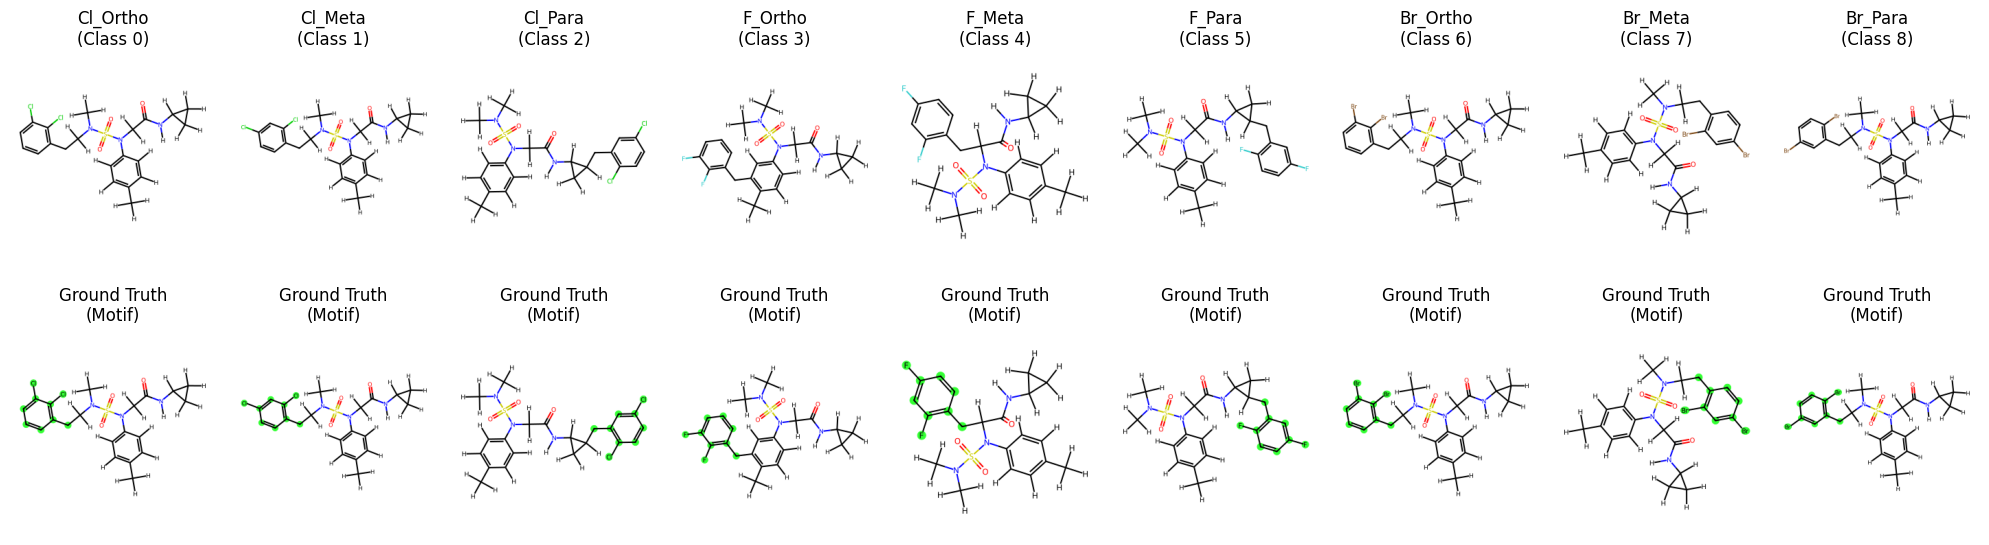

In [26]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import torch
import numpy as np

# ---------------------------------------------------------
# 1. HELPER: Convert PyG Data back to RDKit Mol
# ---------------------------------------------------------
def pyg_to_rdkit(data):
    """
    Reconstructs an RDKit molecule from a PyG Data object.
    """
    atom_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    bond_list = [Chem.BondType.SINGLE, Chem.BondType.DOUBLE, 
                 Chem.BondType.TRIPLE, Chem.BondType.AROMATIC]
    
    mol = Chem.RWMol()
    
    # 1. Add Atoms
    # data.x is [num_nodes, num_features]
    node_features = data.x.cpu().detach().numpy()
    for feat in node_features:
        atom_idx = np.argmax(feat)
        atom_symbol = atom_list[atom_idx]
        mol.AddAtom(Chem.Atom(atom_symbol))
        
    # 2. Add Bonds
    # data.edge_index is [2, num_edges]
    # data.edge_attr is [num_edges, num_bond_types]
    edge_index = data.edge_index.cpu().detach().numpy()
    edge_attr = data.edge_attr.cpu().detach().numpy()
    
    # Keep track of added bonds to avoid duplicates (since PyG is undirected)
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        i, j = edge_index[0, k], edge_index[1, k]
        
        # Always add bond such that i < j to handle undirected uniqueness
        if i > j: 
            i, j = j, i
            
        if (i, j) in added_bonds:
            continue
            
        bond_type_idx = np.argmax(edge_attr[k])
        bond_type = bond_list[bond_type_idx]
        
        mol.AddBond(int(i), int(j), bond_type)
        added_bonds.add((i, j))
        
    try:
        Chem.SanitizeMol(mol)
    except:
        # Sometimes aromaticity reconstruction is tricky without explicit flags, 
        # but for visualization this usually works fine.
        pass
        
    return mol.GetMol()

# ---------------------------------------------------------
# 2. PLOTTING LOGIC
# ---------------------------------------------------------
def visualize_classes(dataset):
    # Class names for labels
    class_names = [
        'Cl_Ortho', 'Cl_Meta', 'Cl_Para',
        'F_Ortho', 'F_Meta', 'F_Para',
        'Br_Ortho', 'Br_Meta', 'Br_Para'
    ]
    
    # Find one sample for each class
    samples = {}
    for data in dataset:
        label = data.y.item()
        if label not in samples:
            samples[label] = data
        if len(samples) == 9:
            break
            
    # Setup Plot: 2 Rows, 9 Columns
    fig, axes = plt.subplots(2, 9, figsize=(20, 6))
    
    for label in range(9):
        if label not in samples: continue
        
        data = samples[label]
        mol = pyg_to_rdkit(data)
        
        # Identify Motif Atoms from the Mask
        # data.explanation_mask is [num_nodes]
        mask = data.explanation_mask.cpu().numpy()
        motif_atom_indices = [i for i, m in enumerate(mask) if m == 1]
        
        # --- ROW 1: Full Molecule (No Highlight) ---
        img1 = Draw.MolToImage(mol, size=(300, 300))
        axes[0, label].imshow(img1)
        axes[0, label].set_title(f"{class_names[label]}\n(Class {label})")
        axes[0, label].axis('off')
        
        # --- ROW 2: Ground Truth Highlight ---
        # We use highlightAtoms to show the motif
        img2 = Draw.MolToImage(mol, size=(300, 300), 
                               highlightAtoms=motif_atom_indices,
                               highlightColor=(0.2, 1.0, 0.2)) # Green highlight
        
        axes[1, label].imshow(img2)
        axes[1, label].set_title("Ground Truth\n(Motif)")
        axes[1, label].axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. RUN IT
# ---------------------------------------------------------
# Assuming 'dataset_final' is available from your previous step
if len(dataset_final) > 0:
    print("Visualizing samples from the generated dataset...")
    visualize_classes(dataset_final)
else:
    print("Dataset is empty! Run the generation script first.")

--- Visualizing Scaffold #1 ---


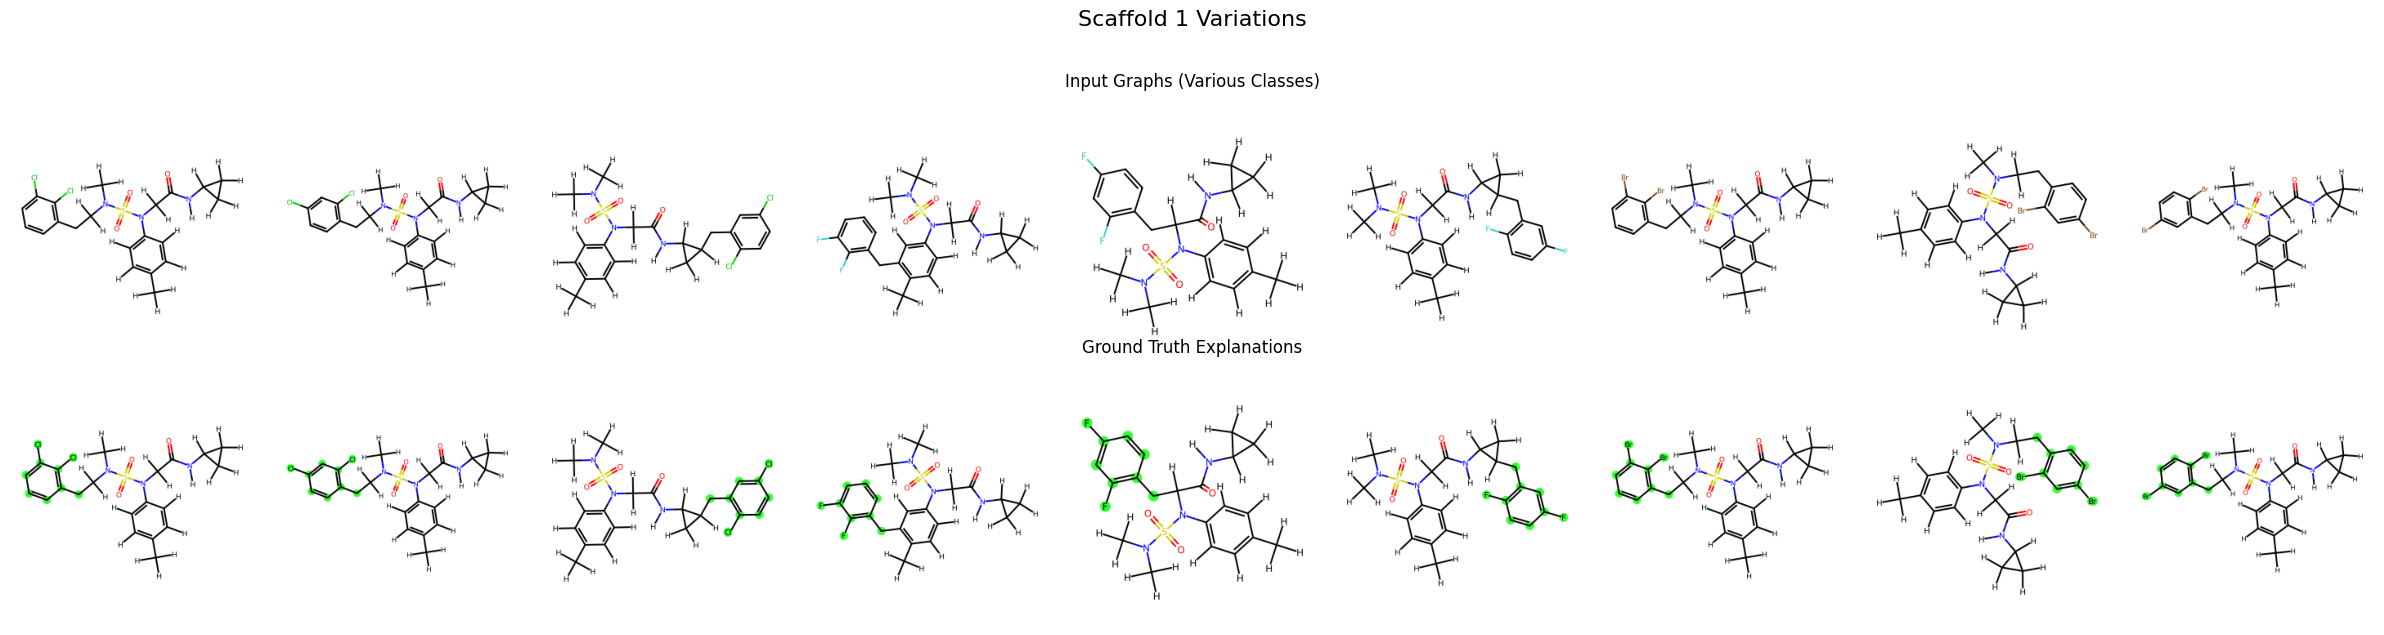



--- Visualizing Scaffold #2 ---


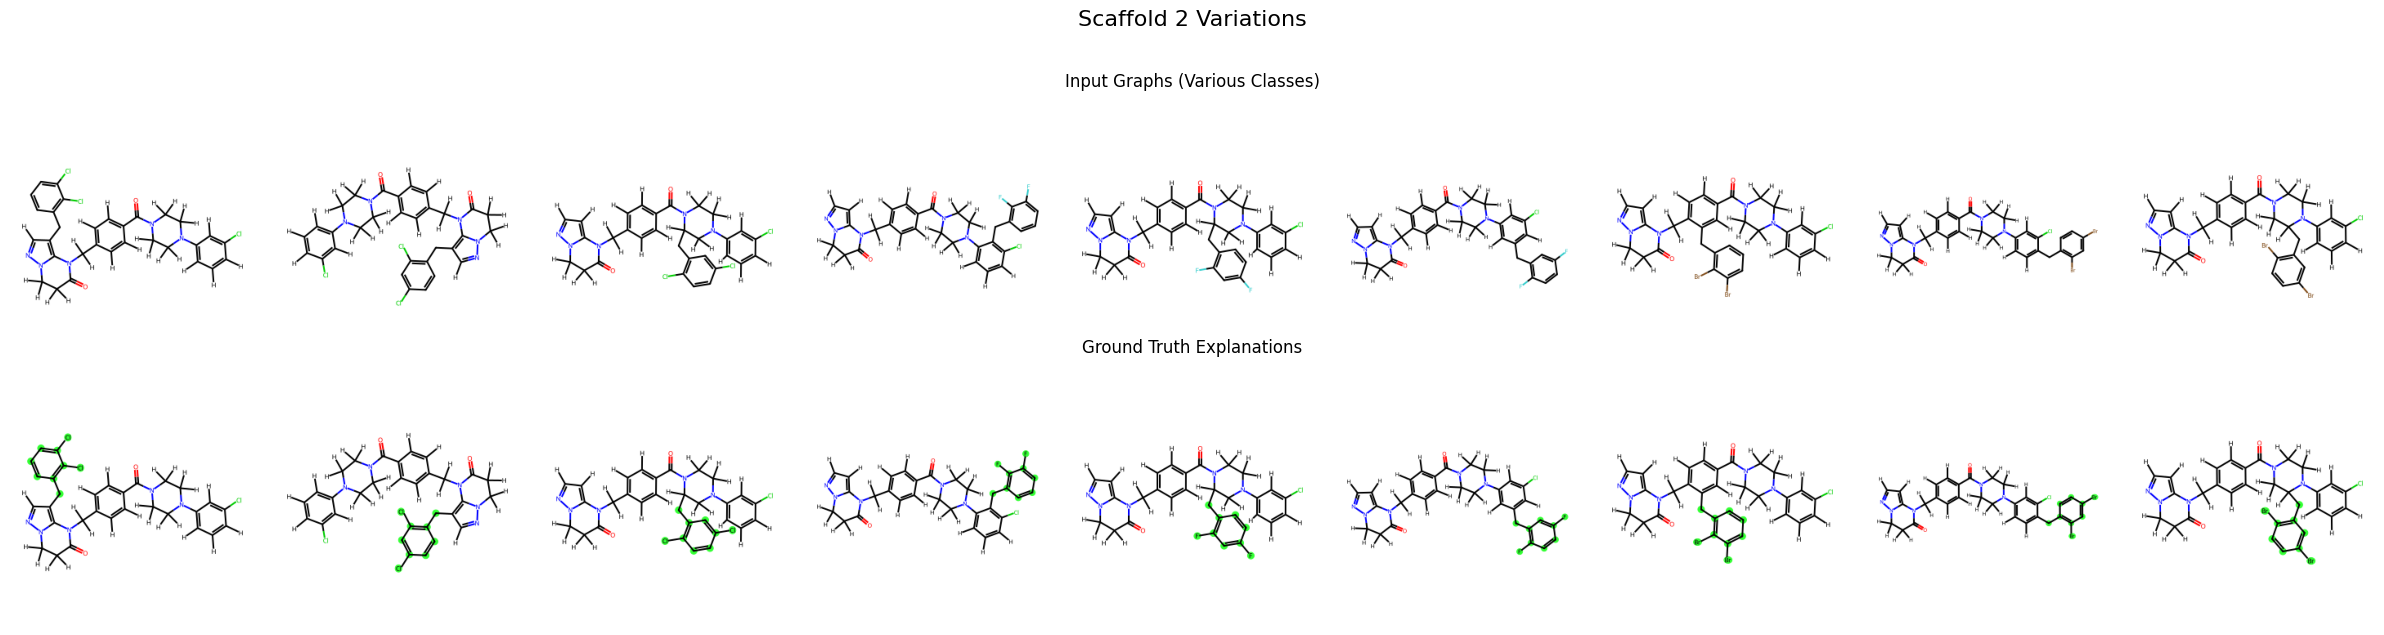



--- Visualizing Scaffold #3 ---


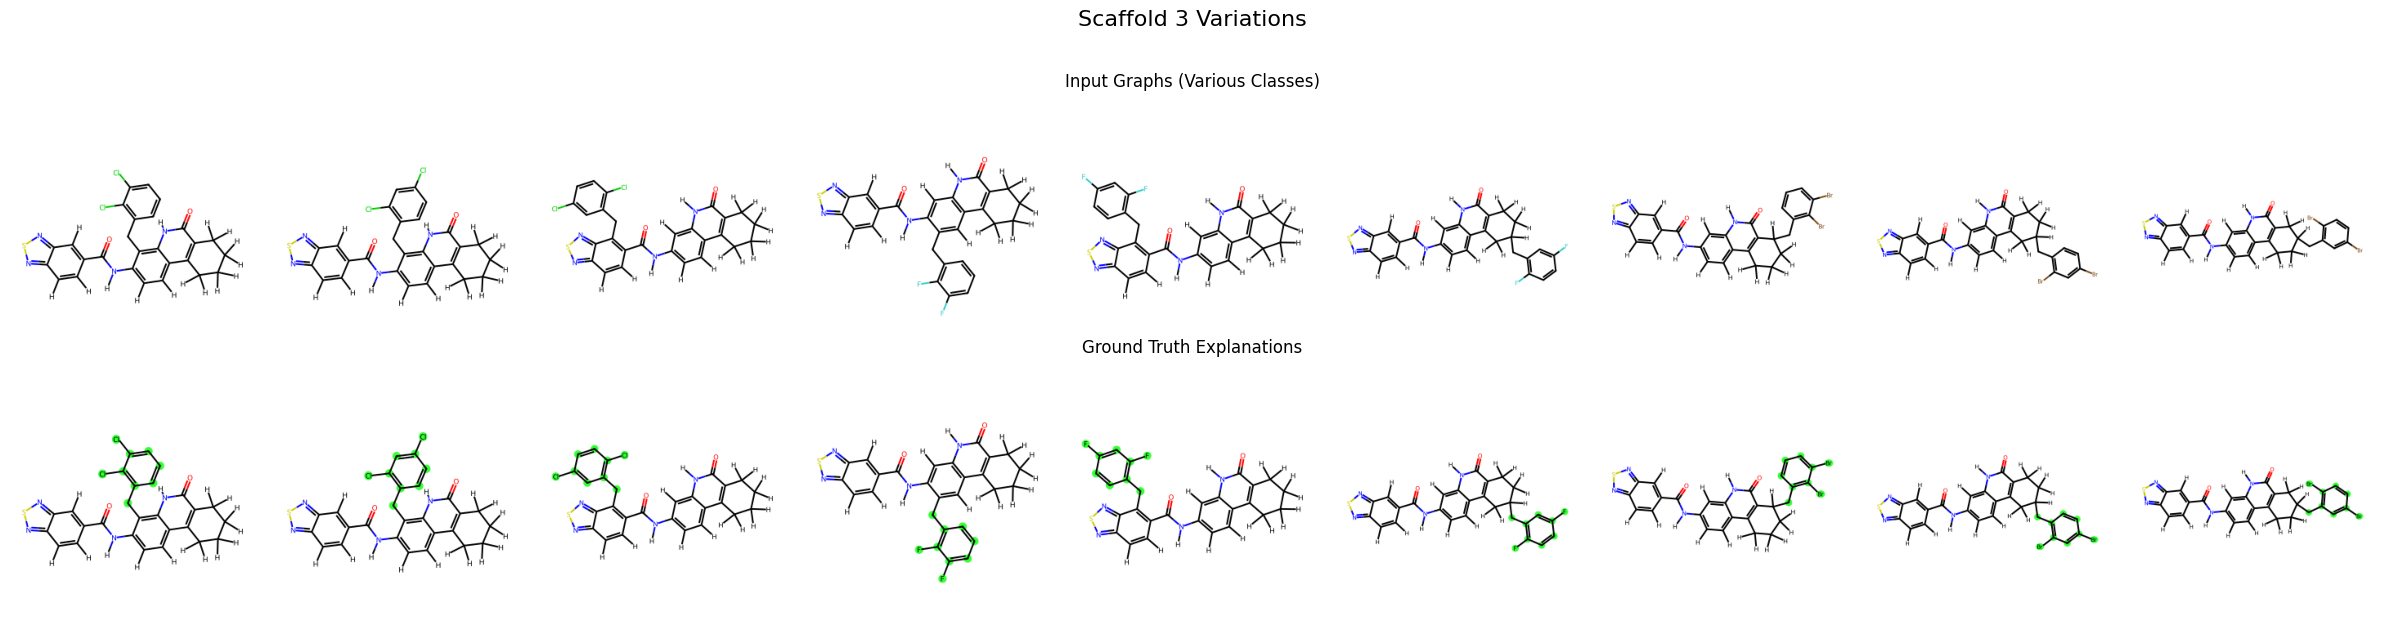



--- Visualizing Scaffold #4 ---


[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 11 N, 4, is greater than permitted


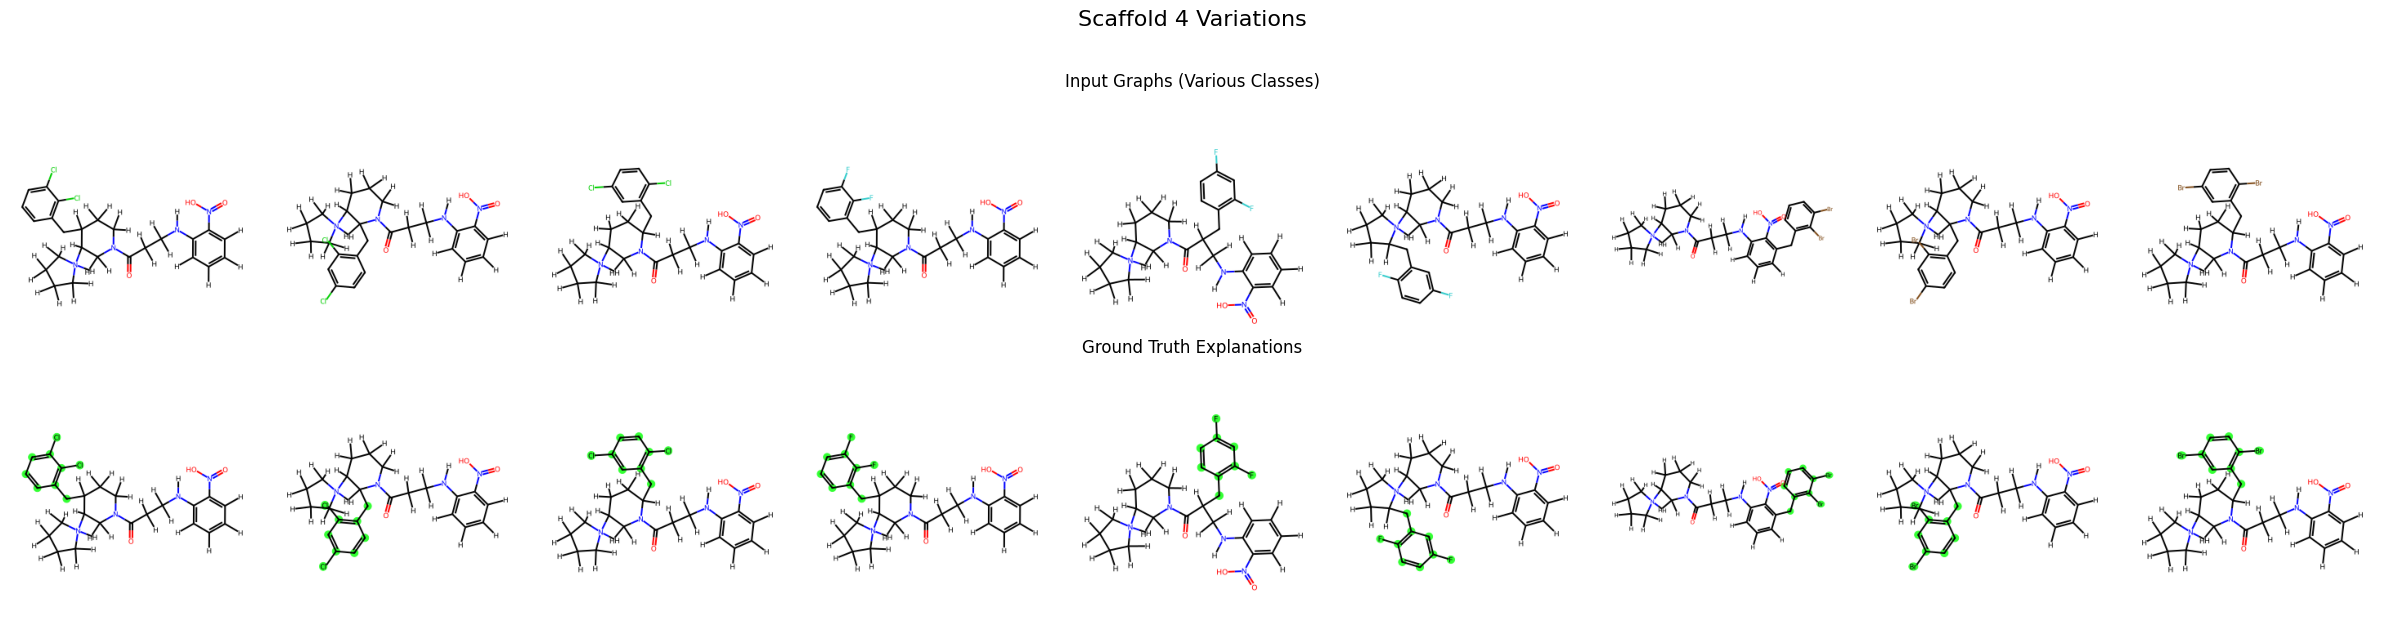



--- Visualizing Scaffold #5 ---


[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted
[03:06:26] Explicit valence for atom # 9 N, 4, is greater than permitted


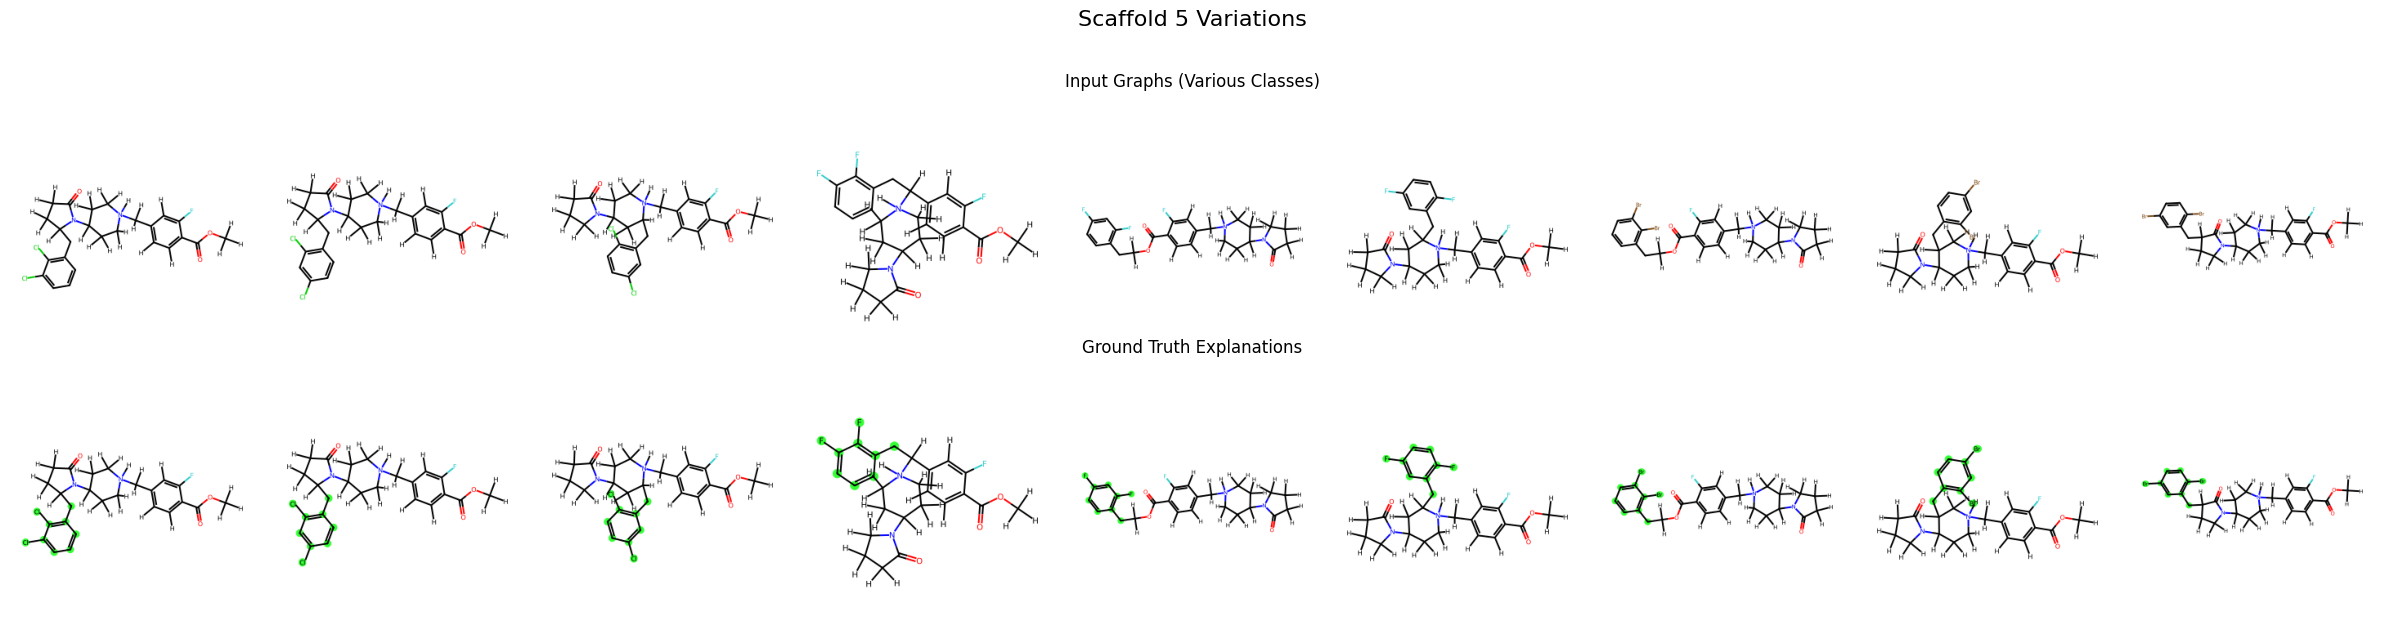



--- Visualizing Scaffold #6 ---


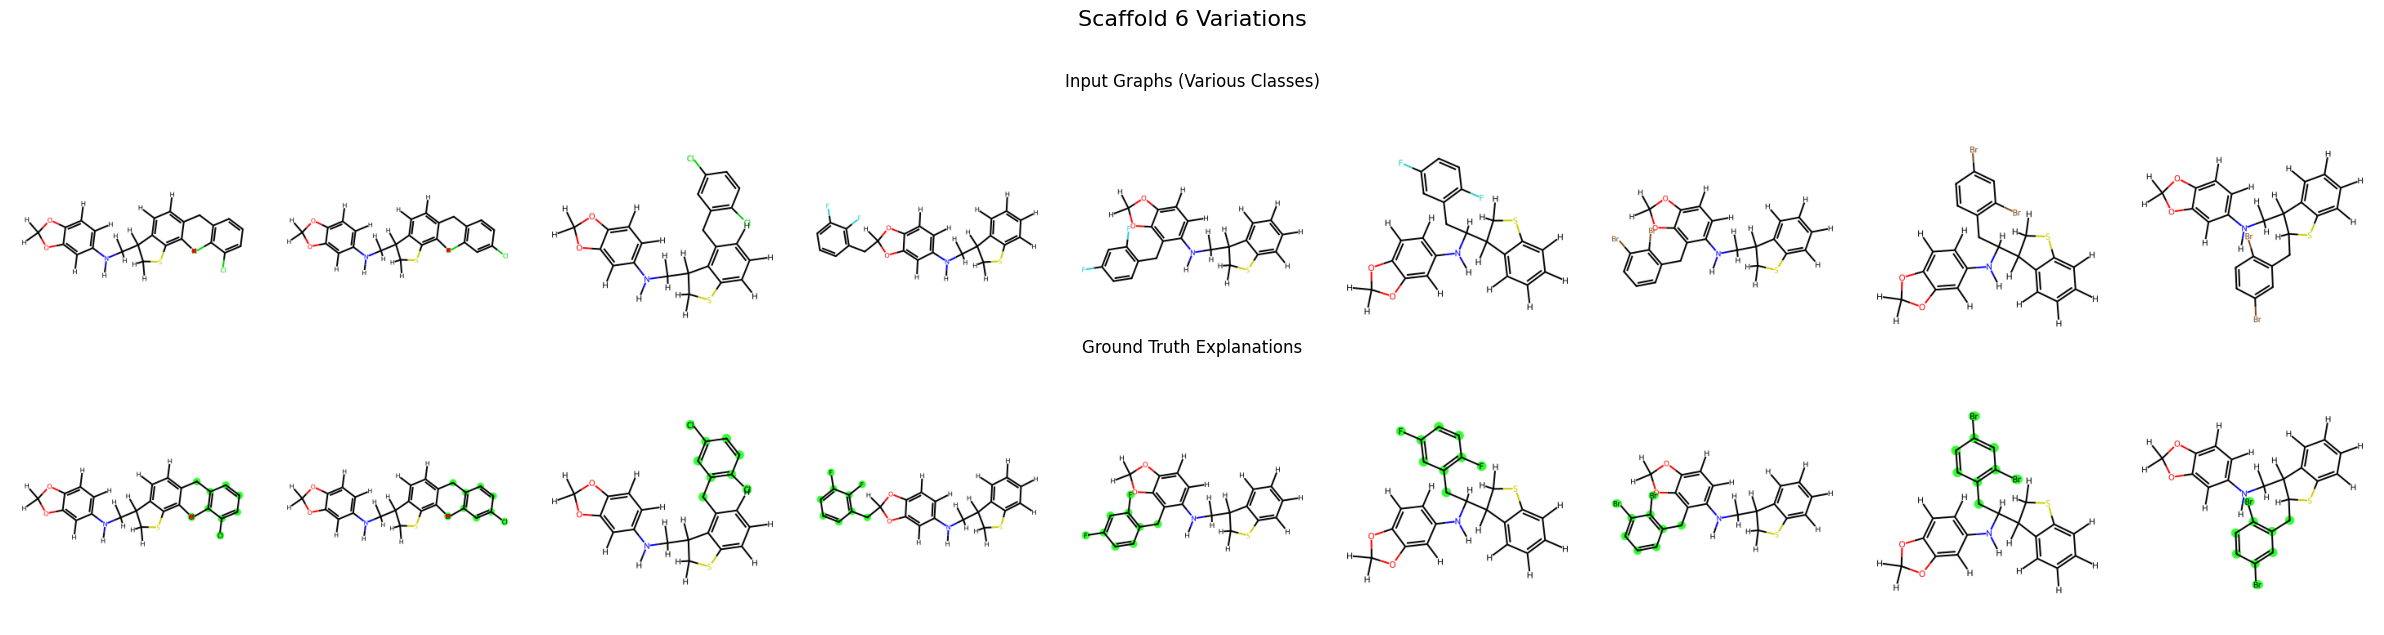

In [27]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import torch
import numpy as np

# ---------------------------------------------------------
# 1. CONVERTER: PyG Data -> RDKit Mol
# ---------------------------------------------------------
def pyg_to_rdkit(data):
    """Reconstructs RDKit molecule from PyG Data object."""
    atom_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    bond_list = [Chem.BondType.SINGLE, Chem.BondType.DOUBLE, 
                 Chem.BondType.TRIPLE, Chem.BondType.AROMATIC]
    
    mol = Chem.RWMol()
    
    # Add Atoms
    node_features = data.x.cpu().detach().numpy()
    for feat in node_features:
        atom_idx = np.argmax(feat)
        atom_symbol = atom_list[atom_idx]
        mol.AddAtom(Chem.Atom(atom_symbol))
        
    # Add Bonds
    edge_index = data.edge_index.cpu().detach().numpy()
    edge_attr = data.edge_attr.cpu().detach().numpy()
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        i, j = edge_index[0, k], edge_index[1, k]
        if i > j: i, j = j, i # Undirected check
            
        if (i, j) in added_bonds: continue
            
        bond_type_idx = np.argmax(edge_attr[k])
        bond_type = bond_list[bond_type_idx]
        
        mol.AddBond(int(i), int(j), bond_type)
        added_bonds.add((i, j))
        
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol.GetMol()

# ---------------------------------------------------------
# 2. PLOTTING LOGIC FOR 6 SCAFFOLDS
# ---------------------------------------------------------
def visualize_scaffolds(dataset, num_scaffolds=6):
    class_names = [
        'Cl_Ortho', 'Cl_Meta', 'Cl_Para',
        'F_Ortho', 'F_Meta', 'F_Para',
        'Br_Ortho', 'Br_Meta', 'Br_Para'
    ]
    
    # We generated data in blocks of 9. 
    # Index 0-8 = Scaffold 1, Index 9-17 = Scaffold 2, etc.
    
    for scaffold_idx in range(num_scaffolds):
        start_idx = scaffold_idx * 9
        
        # Safety check if we have enough data
        if start_idx + 9 > len(dataset):
            print(f"Dataset only has {len(dataset)} graphs. Stopping at scaffold {scaffold_idx}.")
            break
            
        print(f"--- Visualizing Scaffold #{scaffold_idx + 1} ---")
        
        # Create a new figure for this scaffold (2 rows, 9 columns)
        fig, axes = plt.subplots(2, 9, figsize=(24, 6))
        plt.suptitle(f"Scaffold {scaffold_idx + 1} Variations", fontsize=16, y=1.05)
        
        # Loop through the 9 classes for this specific scaffold
        for class_idx in range(9):
            data = dataset[start_idx + class_idx]
            mol = pyg_to_rdkit(data)
            
            # Ground Truth Mask Indices
            mask = data.explanation_mask.cpu().numpy()
            motif_indices = [i for i, m in enumerate(mask) if m == 1]
            
            # Row 1: The Generated Graph
            img1 = Draw.MolToImage(mol, size=(300, 300))
            axes[0, class_idx].imshow(img1)
            if class_idx == 4: axes[0, class_idx].set_title("Input Graphs (Various Classes)", pad=20, fontsize=12)
            axes[0, class_idx].axis('off')
            
            # Row 2: Ground Truth Highlight
            # We highlight the motif atoms in Green
            img2 = Draw.MolToImage(mol, size=(300, 300), 
                                   highlightAtoms=motif_indices,
                                   highlightColor=(0.2, 1.0, 0.2))
            
            axes[1, class_idx].imshow(img2)
            axes[1, class_idx].set_xlabel(class_names[class_idx], fontsize=10)
            if class_idx == 4: axes[1, class_idx].set_title("Ground Truth Explanations", pad=20, fontsize=12)
            axes[1, class_idx].axis('off')

        plt.tight_layout()
        plt.show()
        print("\n" + "="*80 + "\n")

# ---------------------------------------------------------
# 3. RUN VISUALIZATION
# ---------------------------------------------------------
if len(dataset_final) > 0:
    visualize_scaffolds(dataset_final, num_scaffolds=6)
else:
    print("Dataset is empty! Please run the generation script first.")

In [36]:
import os
from pathlib import Path
import torch
from torch_geometric.data import InMemoryDataset


def _find_project_root(start: Path) -> Path:
    """Find repo root by searching parents for pyproject/setup markers."""
    markers = ('pyproject.toml', 'setup.py', '.git')
    for p in [start, *start.parents]:
        if any((p / m).exists() for m in markers):
            return p
    return start
  

class ZincGraftDataset(InMemoryDataset):
    """
    Disk-backed wrapper for the generated `dataset_final` list.

    Saves to: <root>/processed/data.pt
    """
    def __init__(self, root: str, data_list=None, transform=None, pre_transform=None):
        self._provided_data_list = data_list
        super().__init__(root, transform, pre_transform)

        if os.path.exists(self.processed_paths[0]):
            self._data, self.slices = torch.load(self.processed_paths[0])
        else:
            if self._provided_data_list is None:
                raise ValueError("data_list must be provided the first time you create this dataset.")
            os.makedirs(self.processed_dir, exist_ok=True)
            self._data, self.slices = self.collate(self._provided_data_list)
            torch.save((self._data, self.slices), self.processed_paths[0])

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        return

    def process(self):
        return


PROJECT_ROOT = _find_project_root(Path.cwd()).resolve()
DATASET_ROOT = str(PROJECT_ROOT / 'shaique_updates' / 'codes' / 'multi_class_Zinc' / 'zinc_di_halo_benzene_data')
dataset = ZincGraftDataset(root=DATASET_ROOT, data_list=dataset_final)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Total Graphs: {len(dataset)}")
print(f"Number of Classes: {dataset.num_classes}")
print(f"Number of Features: {dataset.num_features}")

Processing...
Done!


Project root: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn
Dataset root: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data
Total Graphs: 9000
Number of Classes: 9
Number of Features: 10


In [29]:
import torch
import numpy as np
from collections import Counter

def inspect_dataset_statistics(dataset):
    print("==================================================")
    print("           DATASET STATISTICS REPORT              ")
    print("==================================================")
    
    # 1. Basic Counts
    num_graphs = len(dataset)
    print(f"Total Graphs: {num_graphs}")
    
    # 2. Feature Dimensions (Check first graph)
    sample = dataset[0]
    num_node_features = sample.x.shape[1]
    num_edge_features = sample.edge_attr.shape[1]
    
    print(f"\n[Dimensions]")
    print(f"Node Feature Dim (x):        {num_node_features}")
    print(f"Edge Feature Dim (edge_attr):{num_edge_features}")
    
    # 3. Check One-Hot Encoding Validity
    # We check if features sum to 1 (valid one-hot) or 0 (unknown atom/bond)
    node_sums = sample.x.sum(dim=1)
    edge_sums = sample.edge_attr.sum(dim=1)
    
    is_node_one_hot = torch.all((node_sums == 1) | (node_sums == 0)).item()
    is_edge_one_hot = torch.all((edge_sums == 1) | (edge_sums == 0)).item()
    
    print(f"\n[Encoding Check]")
    print(f"Are Nodes One-Hot?           {is_node_one_hot}") 
    print(f"Are Edges One-Hot?           {is_edge_one_hot}")
    
    # 4. Class Balance
    labels = [data.y.item() for data in dataset]
    class_counts = Counter(labels)
    
    print(f"\n[Class Distribution]")
    print(f"{'Class ID':<10} {'Name':<20} {'Count':<10}")
    print("-" * 40)
    
    class_names = [
        'Cl_Ortho_Me', 'Cl_Meta_Me', 'Cl_Para_Me',
        'F_Ortho_Me',  'F_Meta_Me',  'F_Para_Me',
        'Br_Ortho_Me', 'Br_Meta_Me', 'Br_Para_Me'
    ]
    
    # Check for perfect balance
    imbalance = False
    for i in range(9):
        count = class_counts.get(i, 0)
        print(f"{i:<10} {class_names[i]:<20} {count:<10}")
        if count != num_graphs / 9:
            imbalance = True
            
    if not imbalance:
        print("\nSUCCESS: Dataset is perfectly balanced.")
    else:
        print("\nWARNING: Dataset is NOT perfectly balanced.")

    # 5. Graph Sizes
    num_nodes = [data.num_nodes for data in dataset]
    num_edges = [data.num_edges for data in dataset]
    
    print(f"\n[Graph Topology]")
    print(f"Avg Nodes: {np.mean(num_nodes):.2f} +/- {np.std(num_nodes):.2f}")
    print(f"Avg Edges: {np.mean(num_edges):.2f} +/- {np.std(num_edges):.2f}")

    # 6. GINEConv Readiness Check
    print(f"\n[GINEConv Compatibility]")
    if num_node_features == num_edge_features:
        print("PASS: Node and Edge dims match. Direct addition possible.")
    else:
        print(f"NOTICE: Mismatch ({num_node_features} vs {num_edge_features}).")
        print("ACTION: You must use a Linear projection for edge_attr in your GNN.")

# Run the inspection
inspect_dataset_statistics(dataset)

           DATASET STATISTICS REPORT              
Total Graphs: 9000

[Dimensions]
Node Feature Dim (x):        10
Edge Feature Dim (edge_attr):4

[Encoding Check]
Are Nodes One-Hot?           True
Are Edges One-Hot?           True

[Class Distribution]
Class ID   Name                 Count     
----------------------------------------
0          Cl_Ortho_Me          1000      
1          Cl_Meta_Me           1000      
2          Cl_Para_Me           1000      
3          F_Ortho_Me           1000      
4          F_Meta_Me            1000      
5          F_Para_Me            1000      
6          Br_Ortho_Me          1000      
7          Br_Meta_Me           1000      
8          Br_Para_Me           1000      

SUCCESS: Dataset is perfectly balanced.

[Graph Topology]
Avg Nodes: 51.72 +/- 8.34
Avg Edges: 108.89 +/- 17.80

[GINEConv Compatibility]
NOTICE: Mismatch (10 vs 4).
ACTION: You must use a Linear projection for edge_attr in your GNN.


# 7. Train a 4-layer GINE (5-fold CV + held-out test)
This section trains a 4-layer GINEConv model using a classic pipeline: for each seed we create a stratified train+val vs test split, run 5-fold CV on train+val (with an inner train/val split per fold), and evaluate each fold's best checkpoint on the held-out test set.
We report accuracy mean ± std across all folds and all seeds.

In [30]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=-1)
    return (pred == y).float().mean().item()


class GINE4Layer(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()
        assert num_layers == 4, "This notebook cell implements the requested 4-layer GINE."
        self.dropout = dropout

        self.node_encoder = nn.Linear(in_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(nn=mlp))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x, inplace=True)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)
        return self.classifier(g)

In [31]:
def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    """Returns (trainval_idx, test_idx, folds) where folds is list of (train_idx, val_idx) in index space."""
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))

    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds


def train_one_run(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.2,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
 ):
    set_seed(seed)
    device = device or get_device()

    # Infer dims from dataset
    sample = dataset[0]
    in_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = int(dataset.num_classes) if hasattr(dataset, 'num_classes') else int(torch.unique(torch.tensor([d.y.item() for d in dataset])).numel())

    model = GINE4Layer(
        in_dim=in_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        num_layers=4,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    # Load best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }

In [32]:
def run_multiseed_5fold(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.2,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []
        if verbose:
            print(f"\n=== Seed {seed} ===")
            print(f"TrainVal={len(trainval_idx)} | Test={len(test_idx)}")

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }

In [34]:
# ---- GPU / Environment preflight (recommended on cluster) ----
import torch
import torch_geometric
from torch_geometric.data import Batch

print(f"torch={torch.__version__} | torch.cuda={torch.version.cuda}")
print(f"pyg={torch_geometric.__version__}")
print(f"cuda_available={torch.cuda.is_available()} | cuda_devices={torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"gpu0={torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA not available -> training will run on CPU.")

# Quick forward pass sanity check on selected device
device = get_device()
sample = dataset[0]
b = Batch.from_data_list([sample]).to(device)
probe = GINE4Layer(
    in_dim=int(sample.x.size(-1)),
    edge_dim=int(sample.edge_attr.size(-1)),
    hidden_dim=64,
    num_classes=int(dataset.num_classes),
    num_layers=4,
).to(device)
with torch.no_grad():
    out = probe(b)
print(f"sanity_forward: device={device} | out_shape={tuple(out.shape)}")

torch=2.9.1 | torch.cuda=None
pyg=2.7.0
cuda_available=False | cuda_devices=0
sanity_forward: device=cpu | out_shape=(1, 9)


In [ ]:
# ---- Config (edit as needed) ----
SEEDS = (0, 1, 2)
K_FOLDS = 5
TEST_SIZE = 0.2  # fraction reserved as a held-out test set per seed

HIDDEN_DIM = 128
BATCH_SIZE = 64
MAX_EPOCHS = 200
DROPOUT = 0.2
WEIGHT_DECAY = 1e-4

LR = 1e-3
SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

VERBOSE = True  # set True for per-epoch logs

# ---- Run ----
results = run_multiseed_5fold(
    dataset,
    seeds=SEEDS,
    k_folds=K_FOLDS,
    test_size=TEST_SIZE,
    hidden_dim=HIDDEN_DIM,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    scheduler_factor=SCHED_FACTOR,
    scheduler_patience=SCHED_PATIENCE,
    min_lr=MIN_LR,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_delta=MIN_DELTA,
    verbose=VERBOSE,
 )

Device: cpu
Seeds: [0, 1, 2] | k_folds=5 | test_size=0.2
LR=0.001 | sched factor=0.5 patience=10 min_lr=1e-06
EarlyStop patience=25 min_delta=0.0001



KeyboardInterrupt: 